## CLASSIFICAÇÃO IRIS - SUPPORT VECTOR MACHINES (SVC)

### PARAMETROS

In [249]:
# PARÂMETROS
random_seed = 42

# FEATURE SELECTION
center_stat = 'mean'

# C
Cs = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
gammas = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
# Cs = [0.0001, 0.001, 0.01]
# gammas = [0.0001, 0.001, 0.01]
kernels = ['rbf']
k_of_k_folds = 5

# GOURMET
palette = ['limegreen', 'indianred', 'gold']

In [250]:
from itertools import product
import numpy
import pandas
import seaborn
from matplotlib import pyplot
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

### IMPORT IRIS

In [251]:
iris_dict = load_iris()
iris = pandas.DataFrame(iris_dict['data'])
iris.columns = iris_dict['feature_names']
iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
iris['target'] = iris_dict['target']
iris['species'] = iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

iris

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


### PAIRPLOT

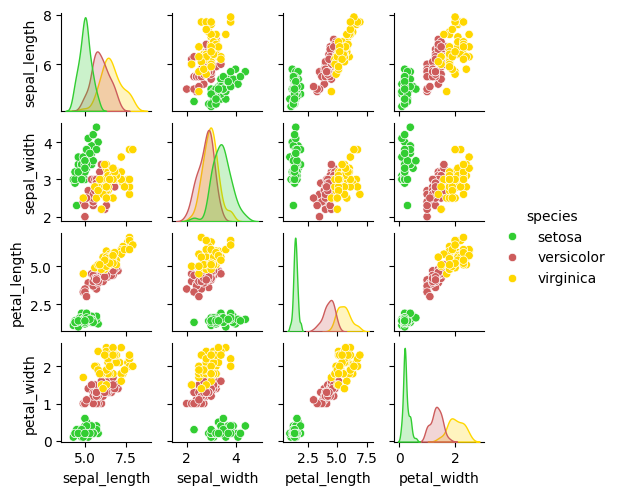

In [252]:
_ = seaborn.pairplot(iris[["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]], hue='species', palette=palette, height=1.25)

### SELEÇÃO DO TOP 2 ATRIBUTOS

In [253]:
all_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
centers = iris.groupby(['species'])[all_cols].agg(center_stat).T
max_diff = (centers.T.max() - centers.T.min()).sort_values(ascending=False)

max_diff

petal_length    4.090
petal_width     1.780
sepal_length    1.582
sepal_width     0.658
dtype: float64

In [254]:
x_cols_sorted = max_diff.index.tolist()[:2]

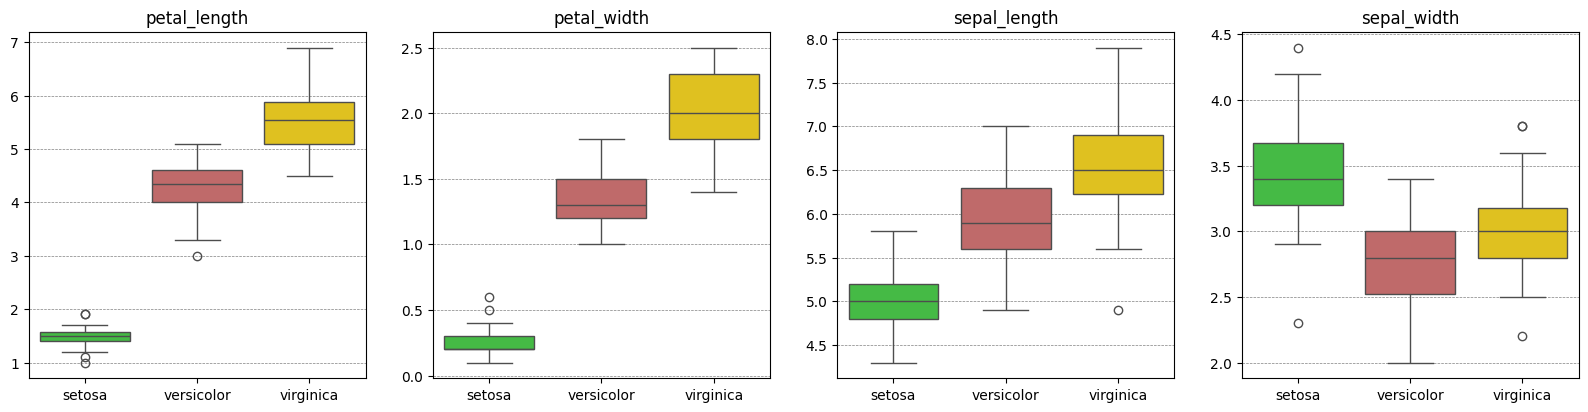

In [255]:
x_cols_sorted = max_diff.index.tolist()

# BOXPLOT DOS ATRIBUTOS VS CLASSE
fig, axs = pyplot.subplots(1, 4, figsize=(20, 4.5))
for i, ax in enumerate(axs.flatten()):
    seaborn.boxplot(x='species', y=x_cols_sorted[i], data=iris, ax=ax, hue='species', dodge=False, palette=palette)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(x_cols_sorted[i])
    ax.grid(which='both', axis='y', color='gray', linestyle='--', linewidth=0.5)

In [256]:
x_cols = x_cols_sorted[:2]

x_cols

['petal_length', 'petal_width']

### LOOP DE TREINAMENTO

> FOLDS VS C

In [257]:
# RANDOM SEED
numpy.random.seed(random_seed)

# LOOP DE TREINAMENTO
ix_model = 0
model_list = []
kfolds = StratifiedKFold(n_splits=k_of_k_folds, shuffle=True, random_state=random_seed)
ix_fold = 0
for train_ix, val_ix in kfolds.split(iris[x_cols], iris['target']):
    X_train, y_train = iris[x_cols].iloc[train_ix], iris['target'].iloc[train_ix]
    X_val, y_val = iris[x_cols].iloc[val_ix], iris['target'].iloc[val_ix]

    # ESCALONAMENTO
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # TREINAMENTO C SVM
    for C in Cs:
        for kernel in kernels:
            for gamma in gammas:
                svm = SVC(C=C,
                          kernel=kernel,
                          gamma=gamma,
                          class_weight='balanced',
                          random_state=random_seed,
                          decision_function_shape='ovo')
                svm.fit(X_train_scaled, y_train)
                y_train_pred = svm.predict(X_train_scaled)
                y_val_pred = svm.predict(X_val_scaled)
                train_accuracy = accuracy_score(y_train, y_train_pred)
                val_accuracy = accuracy_score(y_val, y_val_pred)
                algorithm = 'SVM'
                # model_name = f"SVM-{str(k).zfill(2)}-{100.0*db_size:.0f}-{ix_fold}"
                model_name = f"SVM-C{C}-G{gamma}-{kernel[:3].upper()}-{ix_fold}"
                hyperparameter = f"{kernel[:3].upper()}C{C}G{gamma}"
                print(f"{model_name} > treino: {100.0*train_accuracy:.1f}% | val: {100.0*val_accuracy:.1f}%")
                model_list.append({'ix_model': ix_model,
                                    'algorithm': algorithm,
                                    'kernel': kernel,
                                    'C': C,
                                    'gamma': gamma,
                                    'hyperparameter' : hyperparameter,
                                    'fold': ix_fold,
                                    'model_name': model_name,
                                    'stat' : 'train',
                                    'accuracy': accuracy_score(y_train, y_train_pred),
                                    'scaler' : scaler,
                                    'model' : svm})
                model_list.append({'ix_model': ix_model,
                                   'algorithm': algorithm,
                                   'kernel': kernel,
                                   'C': C,
                                   'gamma': gamma,
                                   'hyperparameter' : hyperparameter,
                                   'fold': ix_fold,
                                   'model_name': model_name,
                                   'stat' : 'validation',
                                   'accuracy': accuracy_score(y_val, y_val_pred),
                                   'scaler' : scaler,
                                   'model' : svm})
                ix_model += 1
    ix_fold += 1

SVM-C5-G15-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G16-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G17-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G18-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G19-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G20-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G21-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G22-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G23-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G24-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C5-G25-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G15-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G16-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G17-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G18-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G19-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G20-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G21-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G22-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G23-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G24-RBF-0 > treino: 99.2% | val: 100.0%
SVM-C6-G25-RB

In [258]:
results = pandas.DataFrame(model_list)
results

,ix_model,algorithm,kernel,C,gamma,hyperparameter,fold,model_name,stat,accuracy,scaler,model
0,0,SVM,rbf,5,15,RBFC5G15,0,SVM-C5-G15-RBF-0,train,0.991667,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
1,0,SVM,rbf,5,15,RBFC5G15,0,SVM-C5-G15-RBF-0,validation,1.000000,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
2,1,SVM,rbf,5,16,RBFC5G16,0,SVM-C5-G16-RBF-0,train,0.991667,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
3,1,SVM,rbf,5,16,RBFC5G16,0,SVM-C5-G16-RBF-0,validation,1.000000,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
4,2,SVM,rbf,5,17,RBFC5G17,0,SVM-C5-G17-RBF-0,train,0.991667,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1205,602,SVM,rbf,15,23,RBFC15G23,4,SVM-C15-G23-RBF-4,validation,1.000000,StandardScaler(),"SVC(C=15, class_weight='balanced', decision_fu..."
1206,603,SVM,rbf,15,24,RBFC15G24,4,SVM-C15-G24-RBF-4,train,0.991667,StandardScaler(),"SVC(C=15, class_weight='balanced', decision_fu..."
1207,603,SVM,rbf,15,24,RBFC15G24,4,SVM-C15-G24-RBF-4,validation,1.000000,StandardScaler(),"SVC(C=15, class_weight='balanced', decision_fu..."
1208,604,SVM,rbf,15,25,RBFC15G25,4,SVM-C15-G25-RBF-4,train,0.991667,StandardScaler(),"SVC(C=15, class_weight='balanced', decision_fu..."


C:\Users\User\AppData\Local\Temp\ipykernel_8632\1598701866.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


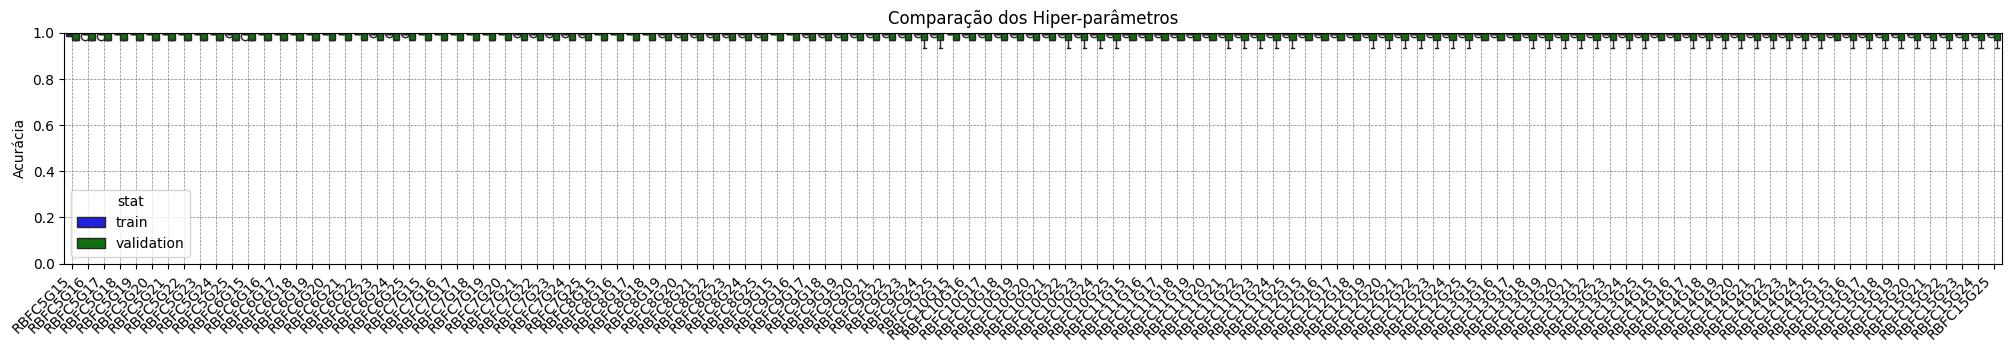

In [259]:
fig = pyplot.figure(figsize=(25, 3))
ax = fig.add_subplot(111)
_ = seaborn.boxplot(x='hyperparameter', y='accuracy', data=results, hue='stat', palette=['blue', 'green'], ax=ax, hue_order=['train', 'validation'])
ax.set_title('Comparação dos Hiper-parâmetros')
ax.set_ylabel('Acurácia')
ax.set_xlabel('')
ax.set_ylim(0.0, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(which='both', color='gray', linestyle='--', linewidth=0.5)

### PICK DO MELHOR MODELO

In [260]:
results

,ix_model,algorithm,kernel,C,gamma,hyperparameter,fold,model_name,stat,accuracy,scaler,model
0,0,SVM,rbf,5,15,RBFC5G15,0,SVM-C5-G15-RBF-0,train,0.991667,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
1,0,SVM,rbf,5,15,RBFC5G15,0,SVM-C5-G15-RBF-0,validation,1.000000,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
2,1,SVM,rbf,5,16,RBFC5G16,0,SVM-C5-G16-RBF-0,train,0.991667,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
3,1,SVM,rbf,5,16,RBFC5G16,0,SVM-C5-G16-RBF-0,validation,1.000000,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
4,2,SVM,rbf,5,17,RBFC5G17,0,SVM-C5-G17-RBF-0,train,0.991667,StandardScaler(),"SVC(C=5, class_weight='balanced', decision_fun..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1205,602,SVM,rbf,15,23,RBFC15G23,4,SVM-C15-G23-RBF-4,validation,1.000000,StandardScaler(),"SVC(C=15, class_weight='balanced', decision_fu..."
1206,603,SVM,rbf,15,24,RBFC15G24,4,SVM-C15-G24-RBF-4,train,0.991667,StandardScaler(),"SVC(C=15, class_weight='balanced', decision_fu..."
1207,603,SVM,rbf,15,24,RBFC15G24,4,SVM-C15-G24-RBF-4,validation,1.000000,StandardScaler(),"SVC(C=15, class_weight='balanced', decision_fu..."
1208,604,SVM,rbf,15,25,RBFC15G25,4,SVM-C15-G25-RBF-4,train,0.991667,StandardScaler(),"SVC(C=15, class_weight='balanced', decision_fu..."


In [261]:
ix_validation = results["stat"] == "validation"

mean_accuracy_by_hyperparameter = results.loc[ix_validation, ["hyperparameter", "accuracy"]].groupby(["hyperparameter"]).agg(["mean", "min"]).reset_index()
mean_accuracy_by_hyperparameter.columns = ['h', 'mean_accuracy', 'min_accuracy']
mean_accuracy_by_hyperparameter = mean_accuracy_by_hyperparameter.sort_values(by=['mean_accuracy', 'min_accuracy'], ascending=[False, False])
mean_accuracy_by_hyperparameter

,h,mean_accuracy,min_accuracy
0,RBFC10G15,0.986667,0.966667
1,RBFC10G16,0.986667,0.966667
2,RBFC10G17,0.986667,0.966667
3,RBFC10G18,0.986667,0.966667
4,RBFC10G19,0.986667,0.966667
...,...,...,...
63,RBFC15G23,0.980000,0.933333
64,RBFC15G24,0.980000,0.933333
65,RBFC15G25,0.980000,0.933333
119,RBFC9G24,0.980000,0.933333


### PICK DO MELHOR MODELO

In [262]:
best_hyperparameter_row = mean_accuracy_by_hyperparameter.iloc[0, :]
best_hyperparameter = best_hyperparameter_row['h']
best_hyperparameter

'RBFC10G15'

In [263]:
best_h_results = results.loc[results['hyperparameter'] == best_hyperparameter, :]
best_model_rank = best_h_results.pivot(index='model_name', columns='stat', values='accuracy').sort_values(by=['validation', 'train'], ascending=[False, False])
best_model_row = best_model_rank.iloc[0, :]
best_model_name = best_model_row.name
best_model_name

'SVM-C10-G15-RBF-0'

In [264]:
best_model_row = results.loc[(results['model_name'] == best_model_name) & (results['stat'] == 'validation'), :]
best_model_row

,ix_model,algorithm,kernel,C,gamma,hyperparameter,fold,model_name,stat,accuracy,scaler,model
111,55,SVM,rbf,10,15,RBFC10G15,0,SVM-C10-G15-RBF-0,validation,1.0,StandardScaler(),"SVC(C=10, class_weight='balanced', decision_fu..."


In [265]:
best_model = best_model_row['model'].iloc[0]
best_model_scaler = best_model_row['scaler'].iloc[0]

In [266]:
print(f"Melhor modelo: {best_model_row['model_name'].iloc[0]} > validation: {100.0*best_model_row['accuracy'].iloc[0]:.1f}%")

Melhor modelo: SVM-C10-G15-RBF-0 > validation: 100.0%


### MATRIZ DE CONFUSÃO

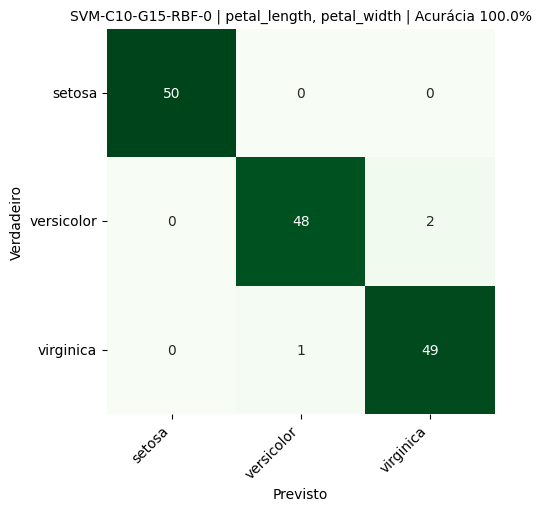

In [267]:
Xs = best_model_scaler.transform(iris[x_cols])
y = iris['target']
winner_y_pred = svm.predict(Xs)


fig = pyplot.figure(figsize=(5, 5))
# PLOT CONFUSION MATRIX
conf_matrix = confusion_matrix(y, winner_y_pred)

ax = fig.add_subplot(111)
_ = seaborn.heatmap(conf_matrix, annot=True, cmap='Greens', cbar=False, ax=ax)
_ = ax.set_xlabel('Previsto')
_ = ax.set_ylabel('Verdadeiro')
_ = ax.set_xticklabels(iris['species'].unique(), rotation=45, ha='right')
_ = ax.set_yticklabels(iris['species'].unique(), rotation=0, ha='right')
# _ = ax.set_title(f'Vencedor: {winner.fk} | treino {100.0*winner_train_accuracy:.0f}% | teste {100.0*winner.hit:.0f}%')
best_feat_string = ', '.join(x_cols)
_ = ax.set_title(f'{best_model_row['model_name'].iloc[0]} | {best_feat_string} | Acurácia {100.0*best_model_row['accuracy'].iloc[0]:.1f}%', size=10)

In [268]:
# CLASS COLOR GRID & CLASS EVALUATION
grid_n_points = 500
species = sorted(iris['species'].unique().tolist())

# X0 W JITTER
X_plot = iris[x_cols].to_numpy()
x0_grid = numpy.linspace(0, X_plot[:, 0].max(), grid_n_points)
x1_grid = numpy.linspace(0, X_plot[:, 1].max(), grid_n_points)
X_g = numpy.array(list(product(x0_grid, x1_grid)))
df_X_g = pandas.DataFrame(X_g, columns=x_cols)
X_g_scaled = best_model_scaler.transform(df_X_g)
Y_g = best_model.predict(X_g_scaled)
Y_g_class = numpy.array([species[x] for x in Y_g])
Y_est = best_model.predict(Xs)
Y_class_est = numpy.array([species[x] for x in Y_est])

In [269]:
species

['setosa', 'versicolor', 'virginica']

In [270]:
color_list = ['steelblue', 'green', 'orange']
background_color_list = ['skyblue', 'limegreen', 'moccasin']
marker_list = ['v', '^', 'v']

# GIVE COLOURS TO CLASS
color_dict = {}
bg_color_dict = {}
marker_dict = {}
ix_color = 0
for specie in species:
    color_dict[specie] = color_list[ix_color]
    marker_dict[specie] = marker_list[ix_color]
    bg_color_dict[specie] = background_color_list[ix_color]
    ix_color += 1

color_dict

{'setosa': 'steelblue', 'versicolor': 'green', 'virginica': 'orange'}

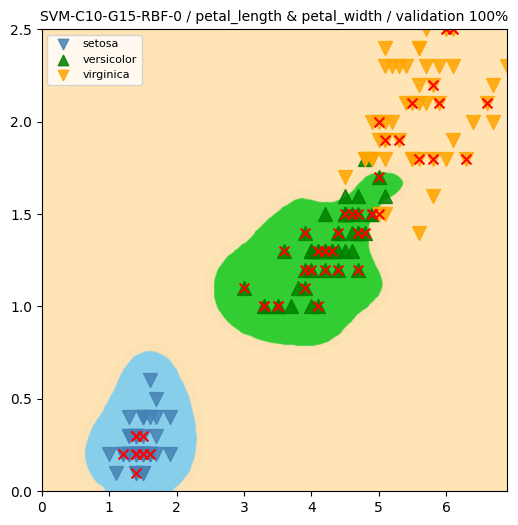

In [271]:
# CLASSIFICATION FIGURE
fig = pyplot.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

# PLOT CLASS REGION
for specie in species:
    ix_class_cloud = Y_g_class == specie
    x_0_cloud = X_g[ix_class_cloud, 0]
    x_1_cloud = X_g[ix_class_cloud, 1]
    _ = ax.scatter(x_0_cloud, x_1_cloud, marker='o', color=bg_color_dict[specie], alpha=0.25)

# PLOR FLOWERS
for specie in species:
    ix_class = iris['species'] == specie
    x_0 = X_plot[ix_class, 0]
    x_1 = X_plot[ix_class, 1]
    _ = ax.scatter(x_0, x_1, color=color_dict[specie], marker=marker_dict[specie], alpha=0.85, s=100, label=specie)
    _ = ax.legend(loc='upper left', fontsize=8, markerscale=0.75)

support_vectors = X_plot[best_model.support_]
_ = ax.scatter(support_vectors[:, 0], support_vectors[:, 1], color='red', marker='x', s=50, label='Support Vectors')
_ = ax.set_xlim([0.0, X_g[:, 0].max()])
_ = ax.set_ylim([0.0, X_g[:, 1].max()])
_ = ax.set_title(f"{best_model_row['model_name'].iloc[0]} / {' & '.join(x_cols)} / validation {100.0*best_model_row['accuracy'].iloc[0]:.0f}%", size=10)

CONFUSÃO + ROC + SUPERFÍCIE DE SEPARAÇÃO MELHOR MODELO

LEARNING CURVE MELHOR K VS REGRESSÃO LOGÍSTICA

FLUTUAÇÃO DOS PARÂMETROS DA REGRESSÃO LOGÍSTICA